# Model Training 

In [1]:
# add project root to the path
import sys
sys.path.append("../")

In [ ]:
from multiple_stage_notebooks import *

## 1. Load prepared data and preprocessor

In [23]:
# load saved preprocessor, train/test splits, feature list and scaled data
# Relative paths (industry-standard structure)
with open("../artifacts/models/preprocessor.pkl", "rb") as f:
    preprocessor = pickle.load(f)

with open("../artifacts/models/preprocessor_for_encoding.pkl", "rb") as f:
    preprocessor_for_encoding = pickle.load(f)

data = np.load("../artifacts/splits/x_y_splits.npz")
X_train_prep = data['X_train_prep']
X_test_prep = data['X_test_prep']
y_train = data['y_train']
y_test = data['y_test']
raw_X_train_prep = data['raw_X_train_prep']
raw_X_test_prep = data['raw_X_test_prep']

with open("../artifacts/features/categorical_cols.json", "r") as f:
    categorical_cols_clean = json.load(f)


scaled_data_X_train = pd.read_csv("../data/processed/scaled_data_X_train.csv")
scaled_data_copy_test_df = pd.read_csv("../data/processed/scaled_data__copy_test_df.csv")

scaled_raw_data_X_train = pd.read_csv("../data/processed/scaled_raw_data_X_train.csv")
scaled_raw_data_X_test = pd.read_csv("../data/processed/scaled_raw_data_X_test.csv")

raw_X_train = pd.read_csv("../data/processed/raw_X_train.csv")
raw_X_test = pd.read_csv("../data/processed/raw_X_test.csv")


Accuracy (baseline sanity check only)
> - **What it is:** % of predictions that were correct overall (`correct / total`).
> - **Why we use it here:** Only as a *quick* first-pass comparison across algorithms — it's not trustworthy on its own for this data since defaults are the minority class (a model predicting "no default" for everyone would still score high).


## 2. Baseline model comparison (kept for reference — not used for final selection)

Accuracy is shown here only as a quick sanity check across algorithms. It is **not** the metric used to pick the final model, since the target is imbalanced (~22% default rate).

In [4]:
# Accuracy (baseline sanity check only, NOT the final selection metric)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
}

def baseline_comparison(X_train, X_test, y_train, y_test, models):
    names, scores = [], []
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        score = accuracy_score(y_test, y_pred)
        names.append(name)
        scores.append(score)
    report = pd.DataFrame({"Model_Name": names, "Accuracy": scores})
    return report.sort_values(by="Accuracy", ascending=False)

baseline_comparison(X_train_prep, X_test_prep, y_train, y_test, models)


,Model_Name,Accuracy
7,CatBoost,0.935476
6,XGBoost,0.933162
1,Random Forest,0.932262
3,Gradient Boosting,0.928406
2,AdaBoost,0.889075
5,Decision Tree,0.881491
4,KNN,0.873522
0,Logistic Regression,0.851542


## 3. Class weight computation for all models (Informative)

In [5]:
# compute balanced class weights for the imbalanced target
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Reference balanced class weights: {class_weight_dict}")


Reference balanced class weights: {0: np.float64(0.6399661542800733), 1: np.float64(2.2861460957178843)}


## 4. Catboost model training with class weight without tuning

In [6]:
# CatBoost training with class weights (handles class imbalance so the minority/default class isn't ignored)
def train_catboost_with_balanced_weights(X_train, cat_features, iterations=50, random_state=42):

    model = CatBoostClassifier(
        iterations=iterations,
        class_weights=class_weight_dict,
        verbose=0,
        random_state=random_state
    )
    model.fit(X_train, y_train, cat_features=cat_features)

    return model

In [7]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, recall_score, precision_score, f1_score
)

def evaluate_model_with_threshold(model, X_test, y_test, model_name="model", tune=False,
                                   display_labels=['No Default', 'Default'], show_threshold_table=False):

    if tune:
        model = model.best_estimator_

    # get predicted probabilities for positive class
    y_proba = model.predict_proba(X_test)[:, 1]

    # threshold search to find best accuracy
    thresholds = np.arange(0.1, 0.91, 0.01)
    best_thresh = 0.5
    best_acc = 0

    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        acc_t = accuracy_score(y_test, y_pred_t)
        if acc_t > best_acc:
            best_acc = acc_t
            best_thresh = t

    print(f"Best Threshold: {best_thresh:.2f}")
    print(f"Best Accuracy: {best_acc:.4f}")

    # final predictions using best threshold
    y_pred = (y_proba >= best_thresh).astype(int)

    acc = accuracy_score(y_test, y_pred)
    clf_report = classification_report(y_test, y_pred)
    print("Accuracy:", acc)
    print("\nClassification Report:\n", clf_report)


    cm = confusion_matrix(y_test, y_pred)
    if not show_threshold_table:
        
        # display via ConfusionMatrixDisplay (not raw array print) with dynamic title
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
        disp.plot(cmap='Blues')
        plt.title(f'Confusion Matrix — {model_name} (threshold {best_thresh:.2f})')
        plt.show()

    # threshold-wise recall/precision/f1 table
    if show_threshold_table:
        report_thresholds = np.arange(0.1, 0.99, 0.03).round(2)
        print(f"\n{'Threshold':>9} | {'Recall':>6} | {'Precision':>9} | {'F1-Score':>8}")
        print("-" * 50)
        for t in report_thresholds:
            y_pred_t = (y_proba >= t).astype(int)
            recall = recall_score(y_test, y_pred_t)
            precision = precision_score(y_test, y_pred_t, zero_division=0)
            f1 = f1_score(y_test, y_pred_t)
            print(f"{t:>9} | {recall:>6.2f} | {precision:>9.2f} | {f1:>8.2f}")

    return model, acc, clf_report, cm, best_thresh

Best Threshold: 0.75
Best Accuracy: 0.9339
Accuracy: 0.9339331619537276

Classification Report:
               precision    recall  f1-score   support

       False       0.93      0.99      0.96      6079
        True       0.96      0.73      0.83      1701

    accuracy                           0.93      7780
   macro avg       0.95      0.86      0.89      7780
weighted avg       0.94      0.93      0.93      7780



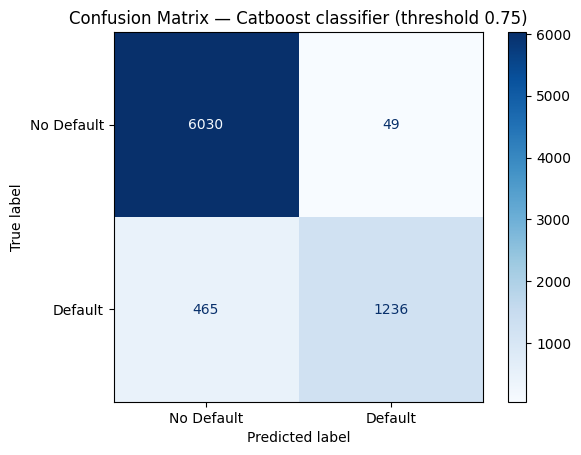

In [8]:
# train CatBoost on raw (non-WOE) features with class-balanced weights
catb_model = train_catboost_with_balanced_weights(
    raw_X_train, 
    categorical_cols_clean)

# evaluate the trained CatBoost model across thresholds (accuracy, report, confusion matrix)
catb_model, catb_acc, catb_clf_report, catb_cm, catb_thresh = evaluate_model_with_threshold(
    catb_model, 
    raw_X_test, 
    y_test, 
    "Catboost classifier")

## 4.1 Catboost model training with GridSearchCV tuning with Threshold table

In [9]:
# GridSearchCV over CatBoost hyperparameters, tuned for F1 (not accuracy) since data is imbalanced
def catboost_grid_search(X_train, y_train, cat_features=None):
    param_grid = {
        'iterations': [50, 80, 150],
        'depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'l2_leaf_reg': [1, 3, 5, 7],
        'class_weights': [{0: 1, 1: 2}, {0: 1, 1: 3}, {0: 1, 1: 4}],
    }
    cb = CatBoostClassifier(random_state=42, verbose=0)
    grid_search = GridSearchCV(
        estimator=cb, param_grid=param_grid, cv=2, n_jobs=-1, scoring='f1', verbose=1
    )
    grid_search.fit(X_train, y_train, cat_features=cat_features)
    print("Best Params:", grid_search.best_params_)
    print("Best CV F1 Score:", grid_search.best_score_)
    return grid_search


In [10]:
# run the grid search to find the best-tuned CatBoost model (by F1)
catboost_grid_search_result = catboost_grid_search(raw_X_train, y_train, cat_features=categorical_cols_clean)
# evaluate the tuned model with threshold tuning enabled to find the best precision/recall trade-off
catb_tuned_model, catb_best_acc, catb_best_clf_report, cat_best_cm, catb_best_thresh = evaluate_model_with_threshold(
    catboost_grid_search_result, raw_X_test, y_test, "Catboost classifier", tune=True, show_threshold_table=True
)

Fitting 2 folds for each of 324 candidates, totalling 648 fits
Best Params: {'class_weights': {0: 1, 1: 2}, 'depth': 8, 'iterations': 150, 'l2_leaf_reg': 1, 'learning_rate': 0.1}
Best CV F1 Score: 0.8089211481699323
Best Threshold: 0.66
Best Accuracy: 0.9347
Accuracy: 0.9347043701799486

Classification Report:
               precision    recall  f1-score   support

       False       0.93      0.99      0.96      6079
        True       0.97      0.72      0.83      1701

    accuracy                           0.93      7780
   macro avg       0.95      0.86      0.89      7780
weighted avg       0.94      0.93      0.93      7780


Threshold | Recall | Precision | F1-Score
--------------------------------------------------
      0.1 |   0.97 |      0.36 |     0.52
     0.13 |   0.95 |      0.41 |     0.58
     0.16 |   0.92 |      0.47 |     0.63
     0.19 |   0.89 |      0.53 |     0.67
     0.22 |   0.87 |      0.60 |     0.71
     0.25 |   0.84 |      0.65 |     0.73
     0.28 |   

0.32

## 4.2 Confusion matrix based on custom balanced threshold to reduce recall case

In [19]:
# plot a confusion matrix at a given probability threshold (not just the default 0.5)
def show_confusion_matrix_from_prediction(model, X_test, y_test, model_name="model",
                                          display_labels=['No Default', 'Default'], threshold=0.5):

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    print(f"acc_score : {accuracy_score(y_test, y_pred)}")
    print(f"\nclassification report : \n{classification_report(y_test, y_pred)}")
    
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=display_labels, cmap='Blues'
    )
    plt.title(f'Confusion Matrix — {model_name} (threshold {threshold:.2f})')
    plt.show()
    return disp, y_pred

acc_score : 0.9046272493573265

classification report : 
              precision    recall  f1-score   support

       False       0.94      0.93      0.94      6079
        True       0.77      0.80      0.79      1701

    accuracy                           0.90      7780
   macro avg       0.86      0.87      0.86      7780
weighted avg       0.91      0.90      0.91      7780



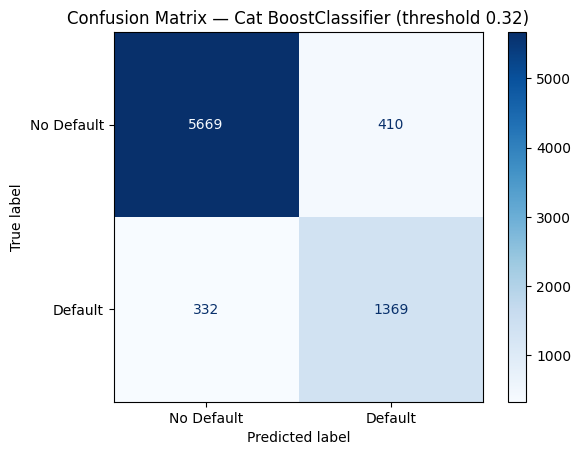

In [20]:
_, catb_y_preds = show_confusion_matrix_from_prediction(catb_tuned_model, raw_X_test, y_test, "Cat BoostClassifier", threshold=0.32)

## 5. XGBoost classifier model training with class weight without tuning

In [21]:
def train_xgb_with_balanced_weights(X_train, iterations=50, random_state=42):
    
    # XGBoost has no class_weights param — convert to per-sample weights
    sample_weights = np.array([class_weight_dict[label] for label in y_train])

    model = XGBClassifier(
        n_estimators=iterations,
        max_depth=8,
        eval_metric='logloss',
        random_state=random_state
    )
    model.fit(X_train, y_train, sample_weight=sample_weights)

    return model

Best Threshold: 0.77
Best Accuracy: 0.9350
Accuracy: 0.9349614395886889

Classification Report:
               precision    recall  f1-score   support

       False       0.93      0.99      0.96      6079
        True       0.97      0.72      0.83      1701

    accuracy                           0.93      7780
   macro avg       0.95      0.86      0.89      7780
weighted avg       0.94      0.93      0.93      7780



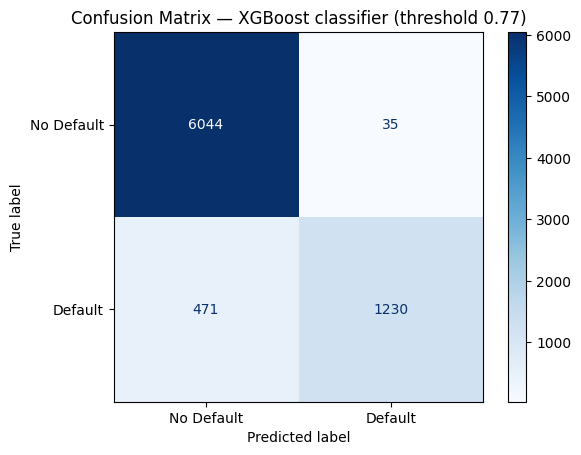

In [24]:
# train XGBoost on scaled raw features with class-balanced weights
xgb_model = train_xgb_with_balanced_weights(
    scaled_raw_data_X_train)

# evaluate the trained XGBoost model across thresholds (accuracy, report, confusion matrix)
xgb_model, xgb_acc, xgb_clf_report, xgb_cm, xgb_thresh = evaluate_model_with_threshold(
    xgb_model,
    scaled_raw_data_X_test,
    y_test,
    "XGBoost classifier"
)

## 5.1 XGBoost classfier model training with GridSearchCV tuning with Threshold table

In [25]:
# GridSearchCV over XGBoost hyperparameters, tuned for F1 (not accuracy) since data is imbalanced
def xgb_grid_search(X_train, y_train):
    param_grid = {
        'n_estimators': [100, 150, 200],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'reg_lambda': [1, 3, 5, 7, 9],
        'scale_pos_weight': [2, 3, 4],  
    }
    xgb = XGBClassifier(random_state=42, eval_metric='logloss')
    grid_search = GridSearchCV(
        estimator=xgb, param_grid=param_grid, cv=3, n_jobs=-1, scoring='f1', verbose=1
    )
    grid_search.fit(X_train, y_train)
    print("Best Params:", grid_search.best_params_)
    print("Best CV F1 Score:", grid_search.best_score_)
    return grid_search

In [26]:
# run the grid search to find the best-tuned XGBoost model (by F1)
xgb_grid_search_result = xgb_grid_search(
    scaled_raw_data_X_train, 
    y_train)
# evaluate the tuned model with threshold tuning enabled to find the best precision/recall trade-off
xgb_tuned_model, xgb_best_acc, xgb_best_clf_report, xgb_best_cm, xgb_best_thresh = evaluate_model_with_threshold(
    xgb_grid_search_result, 
    scaled_raw_data_X_test, 
    y_test, 
    "XGBoost classifier", 
    tune=True,
    show_threshold_table=True
)

Fitting 3 folds for each of 405 candidates, totalling 1215 fits
Best Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 150, 'reg_lambda': 1, 'scale_pos_weight': 2}
Best CV F1 Score: 0.8227538001319292
Best Threshold: 0.69
Best Accuracy: 0.9351
Accuracy: 0.9350899742930592

Classification Report:
               precision    recall  f1-score   support

       False       0.93      0.99      0.96      6079
        True       0.97      0.72      0.83      1701

    accuracy                           0.94      7780
   macro avg       0.95      0.86      0.89      7780
weighted avg       0.94      0.94      0.93      7780


Threshold | Recall | Precision | F1-Score
--------------------------------------------------
      0.1 |   0.96 |      0.40 |     0.57
     0.13 |   0.94 |      0.46 |     0.62
     0.16 |   0.92 |      0.52 |     0.66
     0.19 |   0.91 |      0.57 |     0.70
     0.22 |   0.89 |      0.62 |     0.73
     0.25 |   0.86 |      0.67 |     0.75
     0.28 |   0.

## 5.2 Confusion matrix based on custom balanced threshold to reduce recall case

acc_score : 0.913624678663239

classification report : 
              precision    recall  f1-score   support

       False       0.95      0.94      0.94      6079
        True       0.80      0.80      0.80      1701

    accuracy                           0.91      7780
   macro avg       0.87      0.87      0.87      7780
weighted avg       0.91      0.91      0.91      7780



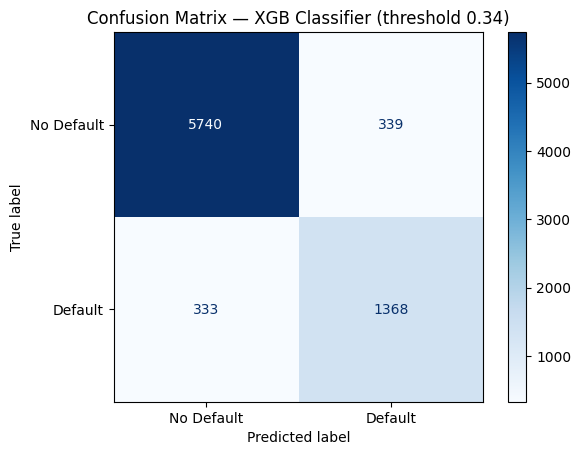

In [28]:
# plot confusion matrix for the tuned XGBoost model at the chosen threshold (0.31)
_, xgb_y_preds = show_confusion_matrix_from_prediction(
    xgb_tuned_model,
    scaled_raw_data_X_test,
    y_test,
    "XGB Classifier",
    threshold=0.34)

## 6. Random Forest classifier model training with classs weight without tunning

Grid search optimizes F1 (better than accuracy for imbalanced data) and searches `class_weight` as a hyperparameter, so this supersedes the earlier manual class-weight and RandomizedSearch attempts.

In [29]:
# train Random Forest with class-balanced weights (handles class imbalance so the minority/default class isn't ignored)
def train_rf_with_balanced_weights(X_train, y_train, n_estimators=50, random_state=42):

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=10,
        class_weight=class_weight_dict,
        random_state=random_state
    )
    model.fit(X_train, y_train)

    return model

Best Threshold: 0.63
Best Accuracy: 0.9297
Accuracy: 0.9296915167095116

Classification Report:
               precision    recall  f1-score   support

       False       0.92      0.99      0.96      6079
        True       0.96      0.71      0.82      1701

    accuracy                           0.93      7780
   macro avg       0.94      0.85      0.89      7780
weighted avg       0.93      0.93      0.93      7780



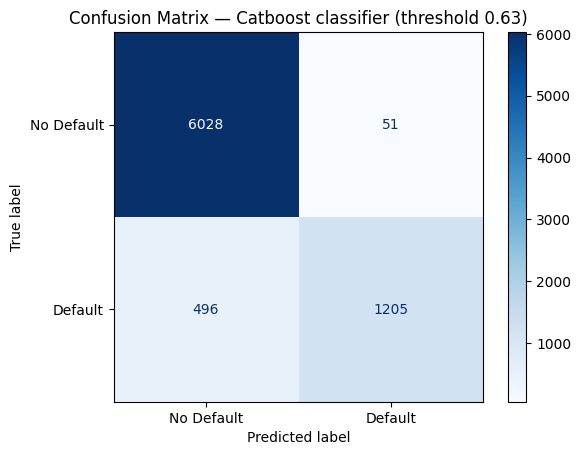

In [30]:
# train Random Forest on preprocessed raw features with class-balanced weights
rf_model = train_rf_with_balanced_weights(
    raw_X_train_prep, 
    y_train)

# evaluate the trained Random Forest model across thresholds (accuracy, report, confusion matrix)
rf_model, rf_acc, rf_clf_report, rf_cm, rf_thresh = evaluate_model_with_threshold(
    rf_model, 
    raw_X_test_prep, 
    y_test, 
    "Catboost classifier")

## 6.1 Random Forest classfier model training with GridSearchCV tuning with Threshold table

In [31]:
# GridSearchCV over Random Forest hyperparameters, tuned for F1 (not accuracy) since data is imbalanced
def rf_grid_search(X_train, y_train):
    param_grid = {
        'n_estimators': [150, 300, 450],
        'max_depth': [10, 20, 30],
        'min_samples_split': [2, 5, 8],
        'min_samples_leaf': [1, 2, 3, 4],
        'max_features': ['sqrt', 'log2'],
        'class_weight': [{0: 1, 1: 2}, {0: 1, 1: 3}, {0: 1, 1: 4}],
    }
    rf = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(
        estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, scoring='f1', verbose=1
    )
    grid_search.fit(X_train, y_train)
    print("Best Params:", grid_search.best_params_)
    print("Best CV F1 Score:", grid_search.best_score_)
    return grid_search

In [32]:
# run the grid search to find the best-tuned Random Forest model (by F1)
rf_grid_search_result = rf_grid_search(
    raw_X_train_prep, 
    y_train)
# evaluate the tuned model with threshold tuning enabled to find the best precision/recall trade-off
rf_tuned_model, rf_best_acc, rf_best_clf_report, rf_best_cm, rf_best_thresh = evaluate_model_with_threshold(
    rf_grid_search_result, 
    scaled_raw_data_X_test, 
    y_test, 
    "Random Forest classifier", 
    tune=True,
    show_threshold_table=True
)

Fitting 3 folds for each of 648 candidates, totalling 1944 fits
Best Params: {'class_weight': {0: 1, 1: 2}, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best CV F1 Score: 0.8148607855249376


c:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Best Threshold: 0.56
Best Accuracy: 0.9323
Accuracy: 0.9322622107969152

Classification Report:
               precision    recall  f1-score   support

       False       0.92      1.00      0.96      6079
        True       0.98      0.71      0.82      1701

    accuracy                           0.93      7780
   macro avg       0.95      0.85      0.89      7780
weighted avg       0.94      0.93      0.93      7780


Threshold | Recall | Precision | F1-Score
--------------------------------------------------
      0.1 |   0.94 |      0.39 |     0.55
     0.13 |   0.92 |      0.46 |     0.61
     0.16 |   0.88 |      0.52 |     0.66
     0.19 |   0.86 |      0.59 |     0.70
     0.22 |   0.84 |      0.65 |     0.73
     0.25 |   0.81 |      0.71 |     0.76
     0.28 |   0.79 |      0.77 |     0.78
     0.31 |   0.78 |      0.82 |     0.80
     0.34 |   0.77 |      0.85 |     0.81
     0.37 |   0.75 |      0.88 |     0.81
      0.4 |   0.74 |      0.91 |     0.82
     0.43 |   0.73 |

## 6.2 Confusion matrix based on custom balanced threshold to reduce recall case

acc_score : 0.9033419023136247

classification report : 
              precision    recall  f1-score   support

       False       0.94      0.93      0.94      6079
        True       0.77      0.79      0.78      1701

    accuracy                           0.90      7780
   macro avg       0.86      0.86      0.86      7780
weighted avg       0.90      0.90      0.90      7780



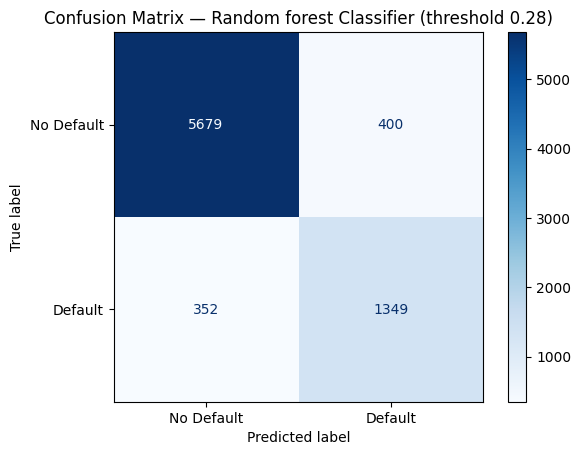

In [33]:
# plot confusion matrix for the tuned Random Forest model at the chosen threshold (0.28)
_, rf_y_preds = show_confusion_matrix_from_prediction(
    rf_tuned_model,
    raw_X_test_prep,
    y_test,
    "Random forest Classifier",
    threshold=0.28)

#### Check for Data Leakage

In [34]:
# function to check for a large train/test accuracy gap (possible leakage)
def check_leakage(model, X_train, y_train, X_test, y_test, threshold=0.05):
    print("\n" + 3*"#", model, 3*"#" + "/n")
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test, model.predict(X_test))
    gap = train_acc - test_acc

    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy:  {test_acc:.4f}")
    print(f"Gap:            {gap:.4f}")

    if gap > threshold:
        print("WARNING: Large train-test gap — possible DATA LEAKAGE or overfitting!")
    else:
        print("Gap is small — model looks safe, no obvious leakage.")



In [35]:
# check for data leakage (train vs. test score gap) across all three tuned models
check_leakage(catb_tuned_model, raw_X_train, y_train, raw_X_test, y_test)
check_leakage(xgb_tuned_model, scaled_raw_data_X_train, y_train, scaled_raw_data_X_test, y_test)
check_leakage(rf_tuned_model, raw_X_train_prep, y_train, raw_X_test_prep, y_test)


### CatBoostClassifier(class_weights={0: 1, 1: 2}, depth=8, iterations=150, l2_leaf_reg=1, learning_rate=0.1, random_state=42, verbose=0) ###/n
Train Accuracy: 0.9397
Test Accuracy:  0.9326
Gap:            0.0071
Gap is small — model looks safe, no obvious leakage.

### XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=No

Business cost (turning FN/FP into ₹)
> - **What it is:** Instead of a generic ML metric, this assigns a real rupee cost to each error type from the confusion matrix — a missed defaulter (FN) costs `fn_cost`, a wrongly rejected good customer (FP) costs `fp_cost` — and sums them.
> - **Why we use it:** Precision/recall tell you *how many* errors happen, not *how much they cost the business* — FN and FP are rarely equally expensive in lending, so this ties the model choice back to an actual financial number.

## 7. Business cost

In [40]:
# Business cost: turns FN/FP counts into a real rupee loss (FN and FP rarely cost the same in lending)
def calculate_business_cost(model, X_test, y_test, model_name="model", threshold=0.5, fn_cost=378, fp_cost=316):
    """Calculates total business loss based on FN/FP misclassification costs at a given threshold."""

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    total_cost = (fn * fn_cost) + (fp * fp_cost)

    print(f"--- {model_name} (threshold {threshold:.2f}) ---\n")
    print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(f"Total Business Loss: Rs. {total_cost}")

    return total_cost

In [43]:
catb_total_cost = calculate_business_cost(catb_tuned_model, raw_X_test, y_test, model_name='CatBoost Classifier', threshold=0.31)
print(f"Total cost for CatBoost Classifier: {catb_total_cost}\n")

xgb_total_cost = calculate_business_cost(xgb_tuned_model, scaled_raw_data_X_test, y_test, model_name='XGBoost Classifier', threshold=0.28)
print(f"Total cost for XGBoost Classifier: {xgb_total_cost}\n")

rf_total_cost = calculate_business_cost(rf_tuned_model, raw_X_test_prep, y_test, model_name='Random Forest Classifier', threshold=0.31)
print(f"Total cost for Random Forest Classifier: {rf_total_cost}\n")

--- CatBoost Classifier (threshold 0.31) ---

TN=5634, FP=445, FN=327, TP=1374
Total Business Loss: Rs. 264226
Total cost for CatBoost Classifier: 264226

--- XGBoost Classifier (threshold 0.28) ---

TN=5521, FP=558, FN=274, TP=1427
Total Business Loss: Rs. 279900
Total cost for XGBoost Classifier: 279900

--- Random Forest Classifier (threshold 0.31) ---

TN=5785, FP=294, FN=377, TP=1324
Total Business Loss: Rs. 235410
Total cost for Random Forest Classifier: 235410



> #### Based on Loss We will use Random Forest for better efficiency

ROC-AUC & Brier score
> - **What it is:** **ROC-AUC** measures how well the model ranks a random defaulter above a random non-defaulter across *all* thresholds (1.0 = perfect, 0.5 = random guessing). **Brier score** measures how well-calibrated the predicted probabilities are — the mean squared error between predicted probability and actual outcome (lower is better).
> - **Why we use it:** ROC-AUC checks the model's overall discriminative power independent of any one threshold; Brier score checks whether "0.8 probability of default" really behaves like an 80% chance in practice — both matter for a score that will be used for real lending decisions.

## 8. ROC-AUC / Brier score / Precision-Recall curve

In [44]:
# ROC-AUC (ranking ability across thresholds) & Brier score (calibration quality of predicted probabilities)
def evaluate_probability_metrics(model, X_test, y_test, model_name="model"):

    y_proba = model.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_proba)
    brier_score = brier_score_loss(y_test, y_proba)

    print(f"--- {model_name} ---")
    print(f"ROC AUC Score: {roc_auc:.4f}")
    print(f"Brier Score Loss: {brier_score:.4f} (lower is better)")
    print()

    return roc_auc, brier_score

In [45]:
print(f"--- CatBoost Classifier ---")
catb_roc_curve, catb_brier_score = evaluate_probability_metrics(catb_tuned_model, raw_X_test, y_test, model_name="CatBoost Classifier")

print(f"--- XGBoost Classifier ---")
xgb_roc_curve, xgb_brier_score = evaluate_probability_metrics(xgb_tuned_model, scaled_raw_data_X_test, y_test, model_name="XGBoost Classifier")

print(f"--- Random Forest Classifier ---")
rf_roc_curve, rf_brier_score = evaluate_probability_metrics(rf_tuned_model, raw_X_test_prep, y_test, model_name="Random Forest Classifier")

--- CatBoost Classifier ---
--- CatBoost Classifier ---
ROC AUC Score: 0.9397
Brier Score Loss: 0.0598 (lower is better)

--- XGBoost Classifier ---
--- XGBoost Classifier ---
ROC AUC Score: 0.9485
Brier Score Loss: 0.0561 (lower is better)

--- Random Forest Classifier ---
--- Random Forest Classifier ---
ROC AUC Score: 0.9337
Brier Score Loss: 0.0601 (lower is better)



In [46]:
def plot_roc_and_calibration(model, X_test, y_test, model_name="model"):
    """Plots ROC curve and calibration curve side-by-side for a given model."""

    y_proba = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"roc_auc score of {model_name}")
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax[0].plot(fpr, tpr, color='blue', label=f'Model (AUC = {roc_auc:.2f})')
    ax[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
    ax[0].set_xlabel('False Positive Rate'); ax[0].set_ylabel('True Positive Rate')
    ax[0].set_title(f'ROC Curve — {model_name}'); ax[0].legend(); ax[0].grid(True)

    # calibration curve
    prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
    ax[1].plot(prob_pred, prob_true, marker='o', label=model_name)
    ax[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
    ax[1].set_xlabel('Mean predicted probability'); ax[1].set_ylabel('Fraction of positives')
    ax[1].set_title(f'Calibration Curve — {model_name}'); ax[1].legend(); ax[1].grid(True)

    plt.tight_layout()
    plt.show()

    return roc_auc

roc_auc score of CatBoost Classifier


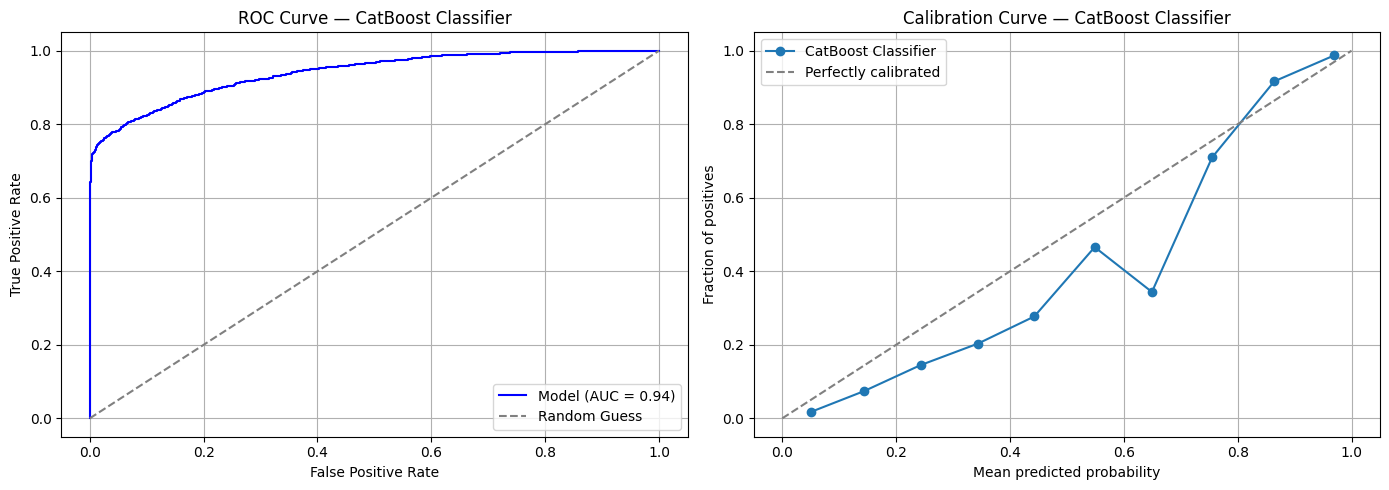

roc_auc score of XGBoost Classifier


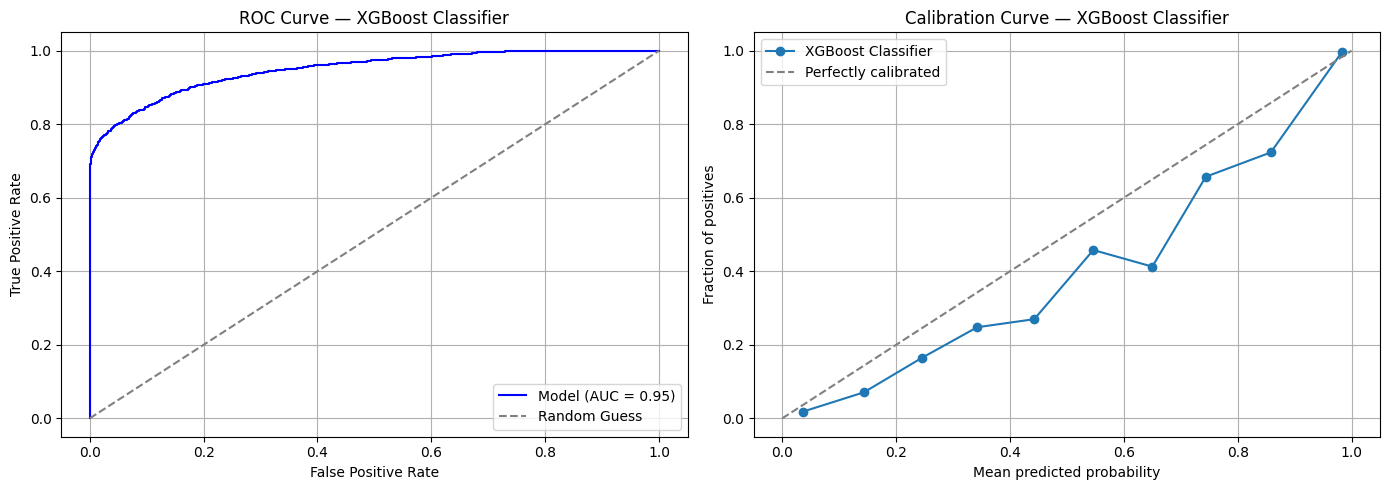

roc_auc score of Random Forest Classifier


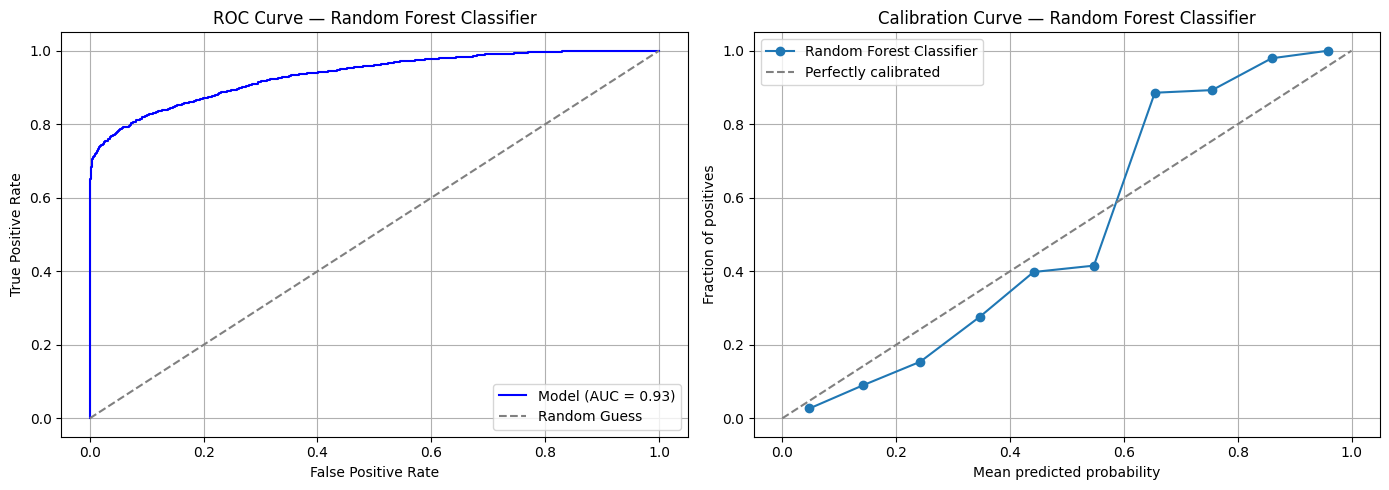

In [47]:
# plot ROC & calibration curves for all three tuned models to compare discrimination and probability quality
catb_roc_auc = plot_roc_and_calibration(catb_tuned_model, raw_X_test, y_test, model_name="CatBoost Classifier")
xgb_roc_auc = plot_roc_and_calibration(xgb_tuned_model, scaled_raw_data_X_test, y_test, model_name="XGBoost Classifier")
rf_roc_auc = plot_roc_and_calibration(rf_tuned_model, raw_X_test_prep, y_test, model_name="Random Forest Classifier")

PR-AUC (Precision-Recall AUC)
> - **What it is:** The area under the Precision-Recall curve — unlike ROC-AUC, it focuses only on how well the model handles the *positive* (minority, default) class as the threshold varies.
> - **Why we use it:** ROC-AUC can look overly optimistic on imbalanced data because it also credits performance on the large majority class. PR-AUC is the more honest metric here since we specifically care about correctly catching the minority "Default" cases.

#### PR-AUC Score

In [48]:
def calculate_pr_auc(model, X_test, y_test, model_name="model"):
    """Calculates Precision-Recall AUC score."""

    y_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)

    print(f"--- {model_name} ---")
    print(f"PR-AUC Score: {pr_auc:.4f}")
    print()

    return pr_auc

In [49]:
# PR-AUC for all three tuned models — more honest than ROC-AUC on this imbalanced (minority=default) data
catb_pr_auc = calculate_pr_auc(catb_tuned_model, raw_X_test, y_test, model_name="CatBoost Classifier")
xgb_pr_auc = calculate_pr_auc(xgb_tuned_model, scaled_raw_data_X_test, y_test, model_name="XGBoost Classifier")
rf_pr_auc = calculate_pr_auc(rf_tuned_model, raw_X_test_prep, y_test, model_name="Random Forest Classifier")

--- CatBoost Classifier ---
PR-AUC Score: 0.8928

--- XGBoost Classifier ---
PR-AUC Score: 0.9049

--- Random Forest Classifier ---
PR-AUC Score: 0.8864



#### Ideal vs Typical PR curve

In [50]:
def plot_pr_curve_vs_ideal(model, X_test, y_test, model_name="model"):
    """Plots the model's Precision-Recall curve against a synthetic 'ideal' curve using Plotly."""

    y_proba = model.predict_proba(X_test)[:, 1]

    # model's actual curve
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    thresholds_padded = np.append(thresholds, thresholds[-1])  # length match karne ke liye

    # fake/synthetic "ideal" curve
    recall_ideal = np.linspace(0, 1, 100)
    precision_ideal = np.where(recall_ideal < 0.7,
                                1 - 0.05 * recall_ideal,
                                1 - 0.05 * 0.7 - 1.5 * (recall_ideal - 0.7))
    precision_ideal = np.clip(precision_ideal, 0, 1)

    # plots
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=recall, y=precision, mode='lines+markers',
        name=model_name,
        line=dict(color='#2a78d6', width=2),
        marker=dict(size=4),
        customdata=thresholds_padded,
        hovertemplate='Recall: %{x:.2f}<br>Precision: %{y:.2f}<br>Threshold: %{customdata:.2f}<extra>' + model_name + '</extra>'
    ))

    # ideal curve
    fig.add_trace(go.Scatter(
        x=recall_ideal, y=precision_ideal, mode='lines',
        name='Ideal (synthetic)',
        line=dict(color='green', width=2.5),
        hovertemplate='Recall: %{x:.2f}<br>Precision: %{y:.2f}<extra>Ideal</extra>'
    ))

    fig.update_layout(
        title=f'Precision-Recall Curve: {model_name} vs Ideal',
        xaxis_title='Recall',
        yaxis_title='Precision',
        xaxis=dict(range=[0, 1]),
        yaxis=dict(range=[0, 1]),
        template='plotly_white',
        legend=dict(x=0.02, y=0.05)
    )

    fig.show()

    return fig

In [51]:
# visualize each model's Precision-Recall curve against the ideal (perfect classifier) curve
_ = plot_pr_curve_vs_ideal(catb_tuned_model, raw_X_test, y_test, model_name="CatBoost Classifier")
_ = plot_pr_curve_vs_ideal(xgb_tuned_model, scaled_raw_data_X_test, y_test, model_name="XGBoost Classifier")
_ = plot_pr_curve_vs_ideal(rf_tuned_model, raw_X_test_prep, y_test, model_name="Random Forest Classifier")

## 9. Top-K high-risk customers

In [57]:
def get_top_risk_customers(model, X_test, y_test, top_n=20, model_name="model"):
    """Returns a DataFrame of the top-N highest-risk customers sorted by predicted probability."""

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    df_precision_k = pd.DataFrame({
        'actual': y_test,
        'pred_class': y_pred,
        'pred_prob': y_proba,
    }).sort_values(by='pred_prob', ascending=False).reset_index(drop=True)

    return df_precision_k.head(top_n)

In [58]:
# pull the top 20 highest-risk customers (by predicted default probability) for each tuned model
catb_model_df_top_k_risky_customers = get_top_risk_customers(catb_tuned_model, raw_X_test, y_test, top_n=20, model_name="CatBoost Classifier")
xgb_model_df_top_k_risky_customers = get_top_risk_customers(xgb_tuned_model, scaled_raw_data_X_test, y_test, top_n=20, model_name="XGBoost Classifier")
rf_model_df_top_k_risky_customers = get_top_risk_customers(rf_tuned_model, raw_X_test_prep, y_test, top_n=20, model_name="Random Forest Classifier")

In [56]:
# how many of the top-20 riskiest customers each model actually predicted as "Default"
catb_model_df_top_k_risky_customers['pred_class'].sum(), xgb_model_df_top_k_risky_customers['pred_class'].sum(), rf_model_df_top_k_risky_customers['pred_class'].sum()

(np.int64(20), np.int64(20), np.int64(20))

> All top 20 high risky customer are predicted default correctly by model 

SHAP feature explanation
> - **What it is:** SHAP (SHapley Additive exPlanations) breaks a single prediction into per-feature contributions — how much each feature pushed the predicted probability up or down for one specific customer.
> - **Why we use it:** A credit decision needs to be explainable (to the customer and to regulators) — "the model said no" isn't enough, we need to show *which* factors drove that specific score.

## 10. SHAP feature explanation 

In [59]:
# SHAP: explain WHY the model gave this specific customer their prediction (per-feature contribution)
def explain_rows_with_shap(model, preprocessor, rows_dict, scaled_data_X_train, threshold=0.5):
    feature_names = scaled_data_X_train.columns
    explainer = shap.TreeExplainer(model)
    for label, raw_row in rows_dict.items():
        row_df = pd.DataFrame([raw_row])
        row_prep = preprocessor.transform(row_df)
        proba = model.predict_proba(row_prep)[:, 1][0]
        decision = "Default" if proba >= threshold else "No Default"
        print(f"{label}: probability={proba:.3f} -> {decision}")
        shap_values = explainer.shap_values(row_prep)
        
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        elif shap_values.ndim == 3:
            shap_values = shap_values[:, :, 1]   # (1, 27, 2) -> (1, 27), class 1 (Default)

        shap.summary_plot(shap_values, row_prep, feature_names=feature_names, plot_type='bar', max_display=len(feature_names), show=False)

        fig = plt.gcf()
        fig.set_size_inches(10, 12)
        plt.tight_layout()
        plt.show()

example_customer: probability=0.510 -> Default


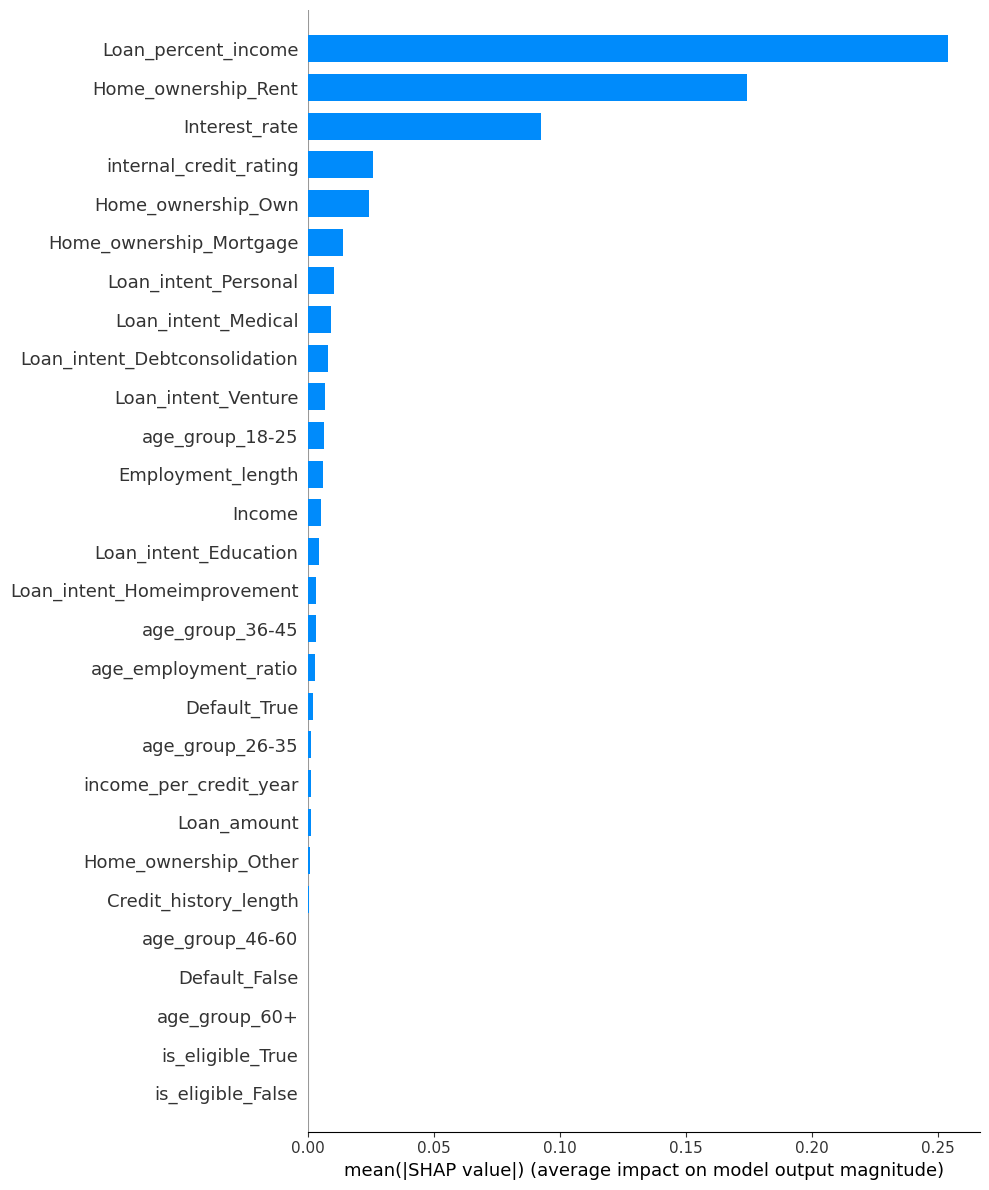

In [69]:
# define an example customer and explain their prediction with SHAP
example_customer = {
    "Income": 35000,
    "Home_ownership": "Mortage",
    "Employment_length": 3,
    "Loan_intent": "Personal",
    "internal_credit_rating": 5,
    "Loan_amount": 12000,
    "Interest_rate": 15.55,
    "Loan_percent_income": 0.34,
    "Default": False,
    "Credit_history_length": 5,
    "credit_score": 785.120,
    "age_group": "36-45",
    "is_eligible": True,
    "high_risk_flag": False,
    "age_employment_ratio": 13.33,
    "income_per_credit_year": 7000
}

explain_rows_with_shap(rf_tuned_model, preprocessor_for_encoding, {"example_customer": example_customer}, scaled_raw_data_X_train, threshold=0.28)


Feature importance
> - **What it is:** Random Forest's built-in ranking of how much each feature reduced impurity across all trees — a *global* (whole-model) view, unlike SHAP which explains one prediction at a time.
> - **Why we use it:** Useful for a high-level sanity check — confirming the model is leaning on sensible risk drivers rather than spurious columns — and for reporting to stakeholders which factors matter most overall.

## 11. Feature importance

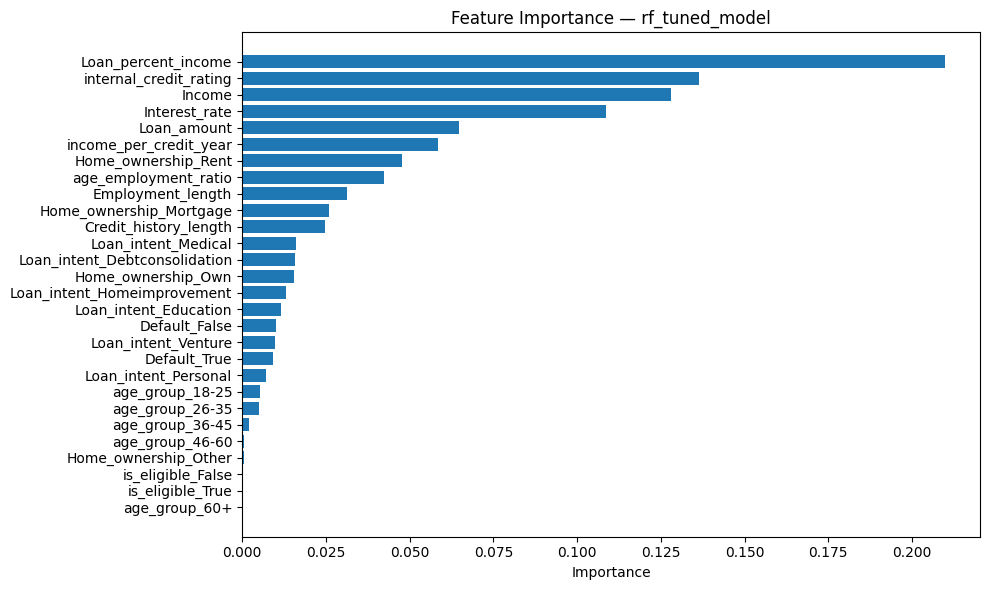

In [70]:
# Feature importance (whole-model view)
feat_imp = pd.DataFrame({
    "feature": scaled_raw_data_X_train.columns,
    "importance": rf_tuned_model.feature_importances_,
}).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.xlabel("Importance")
plt.title("Feature Importance — rf_tuned_model")
plt.tight_layout()
plt.show()


In [71]:

# save model predictions to disk
np.save("../artifacts/predictions/fair_prediction", rf_y_preds)
print("Saved predictions to ../artifacts/predictions/_prediction.npy")


Saved predictions to ../artifacts/predictions/_prediction.npy


In [72]:
def rule_based_risk_flag(customer: dict):
    """Flags a customer as high-risk based on top-5 SHAP-important features using business rules."""

    flags = []

    # Rule 1: Loan_percent_income too high (loan burden relative to income)
    if customer.get("Loan_percent_income", 0) > 0.5:
        flags.append(f"High loan-to-income ratio ({customer['Loan_percent_income']:.2f})")

    # Rule 2: Poor internal credit rating (assuming lower = worse, scale ~1-10)
    if customer.get("internal_credit_rating", 10) <= 4:
        flags.append(f"Low internal credit rating ({customer['internal_credit_rating']})")

    # Rule 3: Low income
    if customer.get("Income", 0) < 20000:
        flags.append(f"Low income (₹{customer['Income']})")

    # Rule 4: High interest rate (indicates lender already sees risk)
    if customer.get("Interest_rate", 0) > 15:
        flags.append(f"High interest rate ({customer['Interest_rate']}%)")

    # Rule 5: Large loan amount
    if customer.get("Loan_amount", 0) > 30000:
        flags.append(f"Large loan amount (₹{customer['Loan_amount']})")

    is_high_risk = len(flags) >= 2  # 2+ red flags → high risk

    print(f"--- Rule-Based Risk Check ---")
    if flags:
        for f in flags:
            print(f"⚠️ {f}")
    else:
        print("✅ No rule violations.")

    print(f"\nFinal Rule-Based Verdict: {'HIGH RISK' if is_high_risk else 'LOW RISK'}")

    return is_high_risk, flags

In [73]:
rule_based_risk_flag(example_customer)

--- Rule-Based Risk Check ---
⚠️ High interest rate (15.55%)

Final Rule-Based Verdict: LOW RISK


(False, ['High interest rate (15.55%)'])

## 12. Save final model + metadata

In [74]:
def save_model_with_metadata(model, model_type, best_params, threshold,
                              roc_auc, brier_score, pr_auc, total_cost,
                              model_name="final_model", save_dir="../artifacts/models",
                              selection_method="GridSearchCV", scoring="f1"):
    """Saves a trained model as pickle + its metadata as JSON."""

    os.makedirs(save_dir, exist_ok=True)

    model_path = os.path.join(save_dir, f"{model_name}.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(model, f)

    metadata = {
        "model_type": model_type,
        "selection_method": selection_method,
        "scoring": scoring,
        "best_params": best_params,
        "final_threshold": threshold,
        "metrics": {
            "roc_auc": round(float(roc_auc), 4),
            "brier_score": round(float(brier_score), 4),
            "pr_auc": round(float(pr_auc), 4),
            "business_cost": int(total_cost),
        },
        "trained_at_utc": datetime.now(timezone.utc).isoformat(),
    }

    metadata_path = os.path.join(save_dir, f"{model_name}_metadata.json")
    with open(metadata_path, "w") as f:
        json.dump(metadata, f, indent=2)

    print(f"Saved {model_name}.pkl and {model_name}_metadata.json")
    print(json.dumps(metadata, indent=2))

    return model_path, metadata_path

In [75]:
save_model_with_metadata(
    model=rf_tuned_model,
    model_type="RandomForestClassifier",
    best_params=rf_grid_search_result.best_params_,
    threshold=0.28,
    roc_auc=rf_roc_auc, brier_score=rf_brier_score, pr_auc=rf_pr_auc, total_cost=rf_total_cost,
    model_name="rf_final_model"
)

save_model_with_metadata(
    model=xgb_tuned_model,
    model_type="XGBClassifier",
    best_params=xgb_grid_search_result.best_params_,
    threshold=31,
    roc_auc=xgb_roc_auc, brier_score=xgb_brier_score, pr_auc=xgb_pr_auc, total_cost=xgb_total_cost,
    model_name="xgb_final_model"
)

save_model_with_metadata(
    model=catb_tuned_model,
    model_type="CatBoostClassifier",
    best_params=catboost_grid_search_result.best_params_,
    threshold=0.31,
    roc_auc=catb_roc_auc, brier_score=catb_brier_score, pr_auc=catb_pr_auc, total_cost=catb_total_cost,
    model_name="catb_final_model"
)

Saved rf_final_model.pkl and rf_final_model_metadata.json
{
  "model_type": "RandomForestClassifier",
  "selection_method": "GridSearchCV",
  "scoring": "f1",
  "best_params": {
    "class_weight": {
      "0": 1,
      "1": 2
    },
    "max_depth": 20,
    "max_features": "sqrt",
    "min_samples_leaf": 2,
    "min_samples_split": 2,
    "n_estimators": 300
  },
  "final_threshold": 0.28,
  "metrics": {
    "roc_auc": 0.9337,
    "brier_score": 0.0601,
    "pr_auc": 0.8864,
    "business_cost": 235410
  },
  "trained_at_utc": "2026-09-12T03:09:12.834095+00:00"
}
Saved xgb_final_model.pkl and xgb_final_model_metadata.json
{
  "model_type": "XGBClassifier",
  "selection_method": "GridSearchCV",
  "scoring": "f1",
  "best_params": {
    "learning_rate": 0.1,
    "max_depth": 6,
    "n_estimators": 150,
    "reg_lambda": 1,
    "scale_pos_weight": 2
  },
  "final_threshold": 31,
  "metrics": {
    "roc_auc": 0.9485,
    "brier_score": 0.0561,
    "pr_auc": 0.9049,
    "business_cost": 27

('../artifacts/models\\catb_final_model.pkl',
 '../artifacts/models\\catb_final_model_metadata.json')